In [11]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import requests
from io import BytesIO

In [12]:
def extract_palette_vector(image_source, n_colors=5, resize=(200, 200), show_palette=True):
    """
    image_source: local file path OR image URL
    n_colors: number of dominant colors to extract
    """

    # Load image from URL or local path
    if image_source.startswith("http://") or image_source.startswith("https://"):
        headers = {
            "User-Agent": "Mozilla/5.0"
        }
        response = requests.get(image_source, headers=headers, timeout=20)
        response.raise_for_status()
        img = Image.open(BytesIO(response.content)).convert("RGB")
    else:
        img = Image.open(image_source).convert("RGB")

    # Resize for speed
    img = img.resize(resize)
    img_array = np.array(img)

    # Flatten pixels
    pixels = img_array.reshape(-1, 3)

    # KMeans clustering
    kmeans = KMeans(n_clusters=n_colors, n_init=10, random_state=42)
    labels = kmeans.fit_predict(pixels)

    colors = kmeans.cluster_centers_.astype(int)

    # Compute proportions
    counts = np.bincount(labels)
    proportions = counts / counts.sum()

    # Sort by most common color
    order = np.argsort(proportions)[::-1]
    colors = colors[order]
    proportions = proportions[order]

    # Build palette vector
    palette_vector = []
    for color, prop in zip(colors, proportions):
        palette_vector.extend(color.tolist())
        palette_vector.append(float(prop))

    palette_vector = np.array(palette_vector)

    # Optional visualization
    if show_palette:
        palette_bar = np.zeros((50, 500, 3), dtype=np.uint8)
        start = 0

        for color, prop in zip(colors, proportions):
            end = start + int(prop * 500)
            palette_bar[:, start:end, :] = color
            start = end

        fig, axes = plt.subplots(2, 1, figsize=(6, 6))
        axes[0].imshow(img_array)
        axes[0].axis("off")
        axes[0].set_title("Image")

        axes[1].imshow(palette_bar)
        axes[1].axis("off")
        axes[1].set_title(f"{n_colors}-Color Palette")

        plt.tight_layout()
        plt.show()

    return palette_vector, colors, proportions

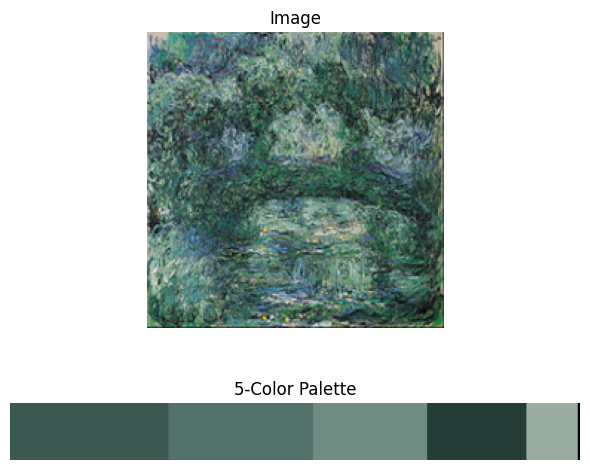

Palette vector shape: (20,)


In [13]:
painting_url = "https://upload.wikimedia.org/wikipedia/commons/thumb/a/a8/Claude_Monet_-_The_Japanese_Bridge_-_Google_Art_Project.jpg/250px-Claude_Monet_-_The_Japanese_Bridge_-_Google_Art_Project.jpg"

palette_vector, colors, proportions = extract_palette_vector(painting_url, n_colors=5)
print("Palette vector shape:", palette_vector.shape)